# Intervention Prioritization

## Business Objective

Convert late-delivery risk predictions into an actionable intervention framework.

The objective is not simply to identify orders with a high probability of delay, but to determine:

1. Which orders deserve immediate attention?
2. Which orders have the greatest potential business impact?
3. Which operational entities contribute disproportionately to risk?
4. What intervention should be prioritized?

The framework combines predicted delivery risk with order value, freight exposure,
customer experience, and operational characteristics.

Final output:

Risk Score → Impact Score → Priority Score → Intervention Tier → Recommended Action

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from urllib.parse import quote_plus

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [3]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

server = r"localhost\SQLEXPRESS"
database = "SupplyChainAnalytics"

connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
)

engine = create_engine(
    "mssql+pyodbc:///?odbc_connect=" +
    quote_plus(connection_string)
)

In [4]:
pd.read_sql(
    "SELECT TOP 5 * FROM dbo.order_analytics",
    engine
)

,order_id,customer_id,customer_unique_id,order_status,customer_city,customer_state,customer_zip_code_prefix,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_count,product_count,seller_count,order_item_value,freight_value,total_order_value,payment_record_count,payment_type_count,total_payment_value,max_payment_installments,review_record_count,distinct_review_count,avg_review_score,min_review_score,max_review_score,processing_days,shipping_days,fulfillment_days,expected_delivery_days,delay_days,is_delivered,is_late,is_not_delivered,delivery_performance_category,delay_severity,has_multiple_items,has_multiple_sellers,order_value_bucket
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,delivered,sao paulo,SP,03149,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,29.9900,8.7200,38.7100,3,2,38.7100,1,1,1,4.0000,4,4,0.0076,2.3667,8.4368,15.5444,-7.1076,1,0,0,Early,No Delay,0,0,Low Value
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,delivered,barreiras,BA,47813,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,118.7000,22.7600,141.4600,1,1,141.4600,1,1,1,4.0000,4,4,1.2799,0.4632,13.7819,19.1382,-5.3563,1,0,0,Early,No Delay,0,0,Medium Value
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,delivered,vianopolis,GO,75265,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,1,1,159.9000,19.2200,179.1200,1,1,179.1200,3,1,1,5.0000,5,5,0.0118,0.2049,9.3944,26.6403,-17.2458,1,0,0,Early,No Delay,0,0,Medium Value
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,delivered,sao goncalo do amarante,RN,59296,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,1,1,45.0000,27.2000,72.2000,1,1,72.2000,1,1,1,5.0000,5,5,0.0118,3.7458,13.2083,26.1889,-12.9806,1,0,0,Early,No Delay,0,0,Low Value
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,delivered,santo andre,SP,09195,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,1,1,19.9000,8.7200,28.6200,1,1,28.6200,1,1,1,5.0000,5,5,0.0431,0.8931,2.8743,12.1125,-9.2382,1,0,0,Early,No Delay,0,0,Low Value


In [5]:
query = """
SELECT *
FROM dbo.order_analytics
"""

df = pd.read_sql(query, engine)

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 99441
Columns: 40


In [6]:
df.head()

,order_id,customer_id,customer_unique_id,order_status,customer_city,customer_state,customer_zip_code_prefix,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_count,product_count,seller_count,order_item_value,freight_value,total_order_value,payment_record_count,payment_type_count,total_payment_value,max_payment_installments,review_record_count,distinct_review_count,avg_review_score,min_review_score,max_review_score,processing_days,shipping_days,fulfillment_days,expected_delivery_days,delay_days,is_delivered,is_late,is_not_delivered,delivery_performance_category,delay_severity,has_multiple_items,has_multiple_sellers,order_value_bucket
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,delivered,campos dos goytacazes,RJ,28013,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,1.0000,1.0000,1.0000,58.9000,13.2900,72.1900,1.0000,1.0000,72.1900,2.0000,1.0000,1.0000,5.0000,5,5,0.0319,6.3674,7.6139,15.6257,-8.0118,1,0,0,Early,No Delay,0,0,Low Value
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,delivered,santa fe do sul,SP,15775,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,1.0000,1.0000,1.0000,239.9000,19.9300,259.8300,1.0000,1.0000,259.8300,3.0000,1.0000,1.0000,4.0000,4,4,0.0083,8.1458,16.2160,18.5465,-2.3306,1,0,0,Early,No Delay,0,0,Medium Value
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,delivered,para de minas,MG,35661,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,1.0000,1.0000,1.0000,199.0000,17.8700,216.8700,1.0000,1.0000,216.8700,5.0000,1.0000,1.0000,5.0000,5,5,0.0104,1.9083,7.9486,21.3938,-13.4451,1,0,0,Early,No Delay,0,0,Medium Value
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,delivered,atibaia,SP,12952,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,1.0000,1.0000,1.0000,12.9900,12.7900,25.7800,1.0000,1.0000,25.7800,2.0000,1.0000,1.0000,4.0000,4,4,0.0069,2.1375,6.1472,11.5833,-5.4361,1,0,0,Early,No Delay,0,0,Low Value
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,delivered,varzea paulista,SP,13226,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,1.0000,1.0000,1.0000,199.9000,18.1400,218.0400,1.0000,1.0000,218.0400,3.0000,1.0000,1.0000,5.0000,5,5,0.0090,11.8167,25.1146,40.4188,-15.3042,1,0,0,Early,No Delay,0,0,Medium Value


In [7]:
print(df.columns.tolist())

['order_id', 'customer_id', 'customer_unique_id', 'order_status', 'customer_city', 'customer_state', 'customer_zip_code_prefix', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_count', 'product_count', 'seller_count', 'order_item_value', 'freight_value', 'total_order_value', 'payment_record_count', 'payment_type_count', 'total_payment_value', 'max_payment_installments', 'review_record_count', 'distinct_review_count', 'avg_review_score', 'min_review_score', 'max_review_score', 'processing_days', 'shipping_days', 'fulfillment_days', 'expected_delivery_days', 'delay_days', 'is_delivered', 'is_late', 'is_not_delivered', 'delivery_performance_category', 'delay_severity', 'has_multiple_items', 'has_multiple_sellers', 'order_value_bucket']


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 40 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   customer_unique_id             99441 non-null  str           
 3   order_status                   99441 non-null  str           
 4   customer_city                  99441 non-null  str           
 5   customer_state                 99441 non-null  str           
 6   customer_zip_code_prefix       99441 non-null  str           
 7   order_purchase_timestamp       99441 non-null  datetime64[us]
 8   order_approved_at              99281 non-null  datetime64[us]
 9   order_delivered_carrier_date   97658 non-null  datetime64[us]
 10  order_delivered_customer_date  96476 non-null  datetime64[us]
 11  order_estimated_delivery_d

In [9]:
df["is_late"] = (
    df["delivery_performance_category"]
    .eq("Late")
    .astype(int)
)

In [10]:
df["is_late"].value_counts()

is_late
0    91614
1     7827
Name: count, dtype: int64

In [11]:
df["is_late"].value_counts(normalize=True) * 100

is_late
0   92.1290
1    7.8710
Name: proportion, dtype: float64

In [12]:
candidate_features = [
    "customer_state",
    "customer_zip_code_prefix",
    "order_item_count",
    "product_count",
    "seller_count",
    "order_item_value",
    "freight_value",
    "total_order_value",
    "payment_record_count",
    "payment_type_count",
    "max_payment_installments"
]

available_features = [
    col for col in candidate_features
    if col in df.columns
]

print("Features used:")
print(available_features)

Features used:
['customer_state', 'customer_zip_code_prefix', 'order_item_count', 'product_count', 'seller_count', 'order_item_value', 'freight_value', 'total_order_value', 'payment_record_count', 'payment_type_count', 'max_payment_installments']


In [13]:
X = df[available_features].copy()
y = df["is_late"]

In [14]:
numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['order_item_count', 'product_count', 'seller_count', 'order_item_value', 'freight_value', 'total_order_value', 'payment_record_count', 'payment_type_count', 'max_payment_installments']
Categorical: ['customer_state', 'customer_zip_code_prefix']


In [15]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [18]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['customer_state','customer_zip_code_prefix','order_item_count',..., 'payment_record_count','payment_type_count','max_payment_installments']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are droppe

In [19]:
df["late_probability"] = rf_model.predict_proba(X)[:, 1]

In [20]:
df[
    [
        "order_id",
        "late_probability",
        "is_late"
    ]
].head(10)

,order_id,late_probability,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,0.5071,0
1,00018f77f2f0320c557190d7a144bdd3,0.4970,0
2,000229ec398224ef6ca0657da4fc703e,0.4968,0
3,00024acbcdf0a6daa1e931b038114c75,0.4817,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,0.4967,0
5,00048cc3ae777c65dbb7d2a0634bc1ea,0.4826,0
6,00054e8431b9d7675808bcb819fb4a32,0.4817,0
7,000576fe39319847cbb9d288c5617fa6,0.4973,0
8,0005a1a1728c9d785b8e2b08b904576c,0.4884,1
9,0005f50442cb953dcd1d21e1fb923495,0.4825,0


In [21]:
df["risk_score"] = (
    df["late_probability"] * 100
)

In [22]:
df["risk_score"].describe()

count   99,441.0000
mean        49.6525
std          1.4780
min         41.4145
25%         48.4749
50%         49.4507
75%         50.7541
max         55.7989
Name: risk_score, dtype: float64

In [23]:
df["risk_band"] = pd.cut(
    df["risk_score"],
    bins=[
        -np.inf,
        25,
        50,
        75,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [24]:
df["risk_band"].value_counts().sort_index()

risk_band
Low              0
Medium       65579
High         33862
Very High        0
Name: count, dtype: int64

In [25]:
df[
    [
        "total_order_value",
        "freight_value"
    ]
].describe()

,total_order_value,freight_value
count,"98,666.0000","98,666.0000"
mean,160.5776,22.8236
std,220.4661,21.6509
min,9.5900,0.0000
25%,61.9800,13.8500
50%,105.2900,17.1700
75%,176.8700,24.0400
max,"13,664.0800","1,794.9600"


In [26]:
df["order_value_score"] = (
    df["total_order_value"]
    .rank(pct=True)
    * 100
)

In [27]:
df["freight_exposure_score"] = (
    df["freight_value"]
    .rank(pct=True)
    * 100
)

In [28]:
if "avg_review_score" in df.columns:
    df["customer_experience_risk"] = (
        6 - df["avg_review_score"]
    ) / 5 * 100
else:
    df["customer_experience_risk"] = 50

In [29]:
df["operational_complexity_score"] = (
    df["order_item_count"].rank(pct=True) * 100
)

In [30]:
df["seller_exposure_score"] = (
    df["seller_count"].rank(pct=True) * 100
)

In [31]:
df["impact_score"] = (
    0.40 * df["order_value_score"]
    + 0.20 * df["freight_exposure_score"]
    + 0.20 * df["operational_complexity_score"]
    + 0.20 * df["customer_experience_risk"]
)

In [32]:
df["impact_score"].describe()

count   97,917.0000
mean        47.5581
std         18.0162
min         13.1950
25%         33.2781
50%         46.6948
75%         60.8110
max         99.9703
Name: impact_score, dtype: float64

In [33]:
df["priority_score"] = (
    0.60 * df["risk_score"]
    + 0.40 * df["impact_score"]
)

In [34]:
df[
    [
        "order_id",
        "risk_score",
        "impact_score",
        "priority_score"
    ]
].sort_values(
    "priority_score",
    ascending=False
).head(20)

,order_id,risk_score,impact_score,priority_score
10751,1baafdbda29613148a2517059b996b95,52.9111,99.3748,71.4965
80842,cfed507ac357129f750f05a0d7d71b15,52.6760,99.6048,71.4475
50863,8339b608be0d84fca9d8da68b58332c3,52.9539,99.1119,71.4171
32956,54d6f9d8f56229d3da815add65ec2408,55.1399,95.4423,71.2608
19142,3182ecdf3da0331bf56a6b4ff5e069d7,52.5873,98.9855,71.1466
49459,7f8df73aeab603648dec28a5f6cfadc3,51.8336,99.7110,70.9846
44830,736e1922ae60d0d6a89247b851902527,51.8340,99.6943,70.9781
1471,03caa2c082116e1d31e67e9ae3700499,51.6243,99.9703,70.9627
9064,17784b9fbb37fb0bdc230d8ed6f6b355,51.7425,99.7275,70.9365
45816,7607b319daef63a1c1a41b1cd6f4a54c,51.5307,99.6443,70.7761


In [35]:
df["intervention_tier"] = pd.cut(
    df["priority_score"],
    bins=[
        -np.inf,
        25,
        50,
        75,
        np.inf
    ],
    labels=[
        "Monitor",
        "Standard Intervention",
        "High Priority",
        "Critical"
    ]
)

In [36]:
df["intervention_tier"].value_counts().sort_index()

intervention_tier
Monitor                      0
Standard Intervention    55176
High Priority            42741
Critical                     0
Name: count, dtype: int64

In [37]:
def assign_action(tier):

    if tier == "Critical":
        return "Immediate operational intervention"

    elif tier == "High Priority":
        return "Prioritize fulfillment monitoring"

    elif tier == "Standard Intervention":
        return "Monitor and review"

    else:
        return "Routine monitoring"

In [38]:
df["recommended_action"] = (
    df["intervention_tier"]
    .map(assign_action)
)

In [39]:
df[
    [
        "order_id",
        "risk_score",
        "impact_score",
        "priority_score",
        "intervention_tier",
        "recommended_action"
    ]
].sort_values(
    "priority_score",
    ascending=False
).head(20)

,order_id,risk_score,impact_score,priority_score,intervention_tier,recommended_action
10751,1baafdbda29613148a2517059b996b95,52.9111,99.3748,71.4965,High Priority,Prioritize fulfillment monitoring
80842,cfed507ac357129f750f05a0d7d71b15,52.6760,99.6048,71.4475,High Priority,Prioritize fulfillment monitoring
50863,8339b608be0d84fca9d8da68b58332c3,52.9539,99.1119,71.4171,High Priority,Prioritize fulfillment monitoring
32956,54d6f9d8f56229d3da815add65ec2408,55.1399,95.4423,71.2608,High Priority,Prioritize fulfillment monitoring
19142,3182ecdf3da0331bf56a6b4ff5e069d7,52.5873,98.9855,71.1466,High Priority,Prioritize fulfillment monitoring
49459,7f8df73aeab603648dec28a5f6cfadc3,51.8336,99.7110,70.9846,High Priority,Prioritize fulfillment monitoring
44830,736e1922ae60d0d6a89247b851902527,51.8340,99.6943,70.9781,High Priority,Prioritize fulfillment monitoring
1471,03caa2c082116e1d31e67e9ae3700499,51.6243,99.9703,70.9627,High Priority,Prioritize fulfillment monitoring
9064,17784b9fbb37fb0bdc230d8ed6f6b355,51.7425,99.7275,70.9365,High Priority,Prioritize fulfillment monitoring
45816,7607b319daef63a1c1a41b1cd6f4a54c,51.5307,99.6443,70.7761,High Priority,Prioritize fulfillment monitoring


In [40]:
priority_validation = (
    df
    .groupby(
        "intervention_tier",
        observed=True
    )
    .agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        avg_risk=("risk_score", "mean"),
        avg_priority=("priority_score", "mean")
    )
    .reset_index()
)

In [41]:
priority_validation["late_rate"] = (
    priority_validation["late_orders"]
    / priority_validation["orders"]
    * 100
)

In [42]:
priority_validation

,intervention_tier,orders,late_orders,avg_risk,avg_priority,late_rate
0,Standard Intervention,55176,3000,49.2036,43.2948,5.4371
1,High Priority,42741,4662,50.2254,55.9367,10.9076


In [43]:
top_100 = (
    df
    .sort_values(
        "priority_score",
        ascending=False
    )
    .head(100)
    .copy()
)

In [44]:
top_100[
    [
        "order_id",
        "late_probability",
        "risk_score",
        "impact_score",
        "priority_score",
        "intervention_tier",
        "recommended_action"
    ]
].head(20)

,order_id,late_probability,risk_score,impact_score,priority_score,intervention_tier,recommended_action
10751,1baafdbda29613148a2517059b996b95,0.5291,52.9111,99.3748,71.4965,High Priority,Prioritize fulfillment monitoring
80842,cfed507ac357129f750f05a0d7d71b15,0.5268,52.6760,99.6048,71.4475,High Priority,Prioritize fulfillment monitoring
50863,8339b608be0d84fca9d8da68b58332c3,0.5295,52.9539,99.1119,71.4171,High Priority,Prioritize fulfillment monitoring
32956,54d6f9d8f56229d3da815add65ec2408,0.5514,55.1399,95.4423,71.2608,High Priority,Prioritize fulfillment monitoring
19142,3182ecdf3da0331bf56a6b4ff5e069d7,0.5259,52.5873,98.9855,71.1466,High Priority,Prioritize fulfillment monitoring
49459,7f8df73aeab603648dec28a5f6cfadc3,0.5183,51.8336,99.7110,70.9846,High Priority,Prioritize fulfillment monitoring
44830,736e1922ae60d0d6a89247b851902527,0.5183,51.8340,99.6943,70.9781,High Priority,Prioritize fulfillment monitoring
1471,03caa2c082116e1d31e67e9ae3700499,0.5162,51.6243,99.9703,70.9627,High Priority,Prioritize fulfillment monitoring
9064,17784b9fbb37fb0bdc230d8ed6f6b355,0.5174,51.7425,99.7275,70.9365,High Priority,Prioritize fulfillment monitoring
45816,7607b319daef63a1c1a41b1cd6f4a54c,0.5153,51.5307,99.6443,70.7761,High Priority,Prioritize fulfillment monitoring


In [45]:
percentiles = [0.01, 0.05, 0.10]

capacity_results = []

for p in percentiles:

    n = int(len(df) * p)

    subset = (
        df
        .sort_values(
            "priority_score",
            ascending=False
        )
        .head(n)
    )

    capacity_results.append({
        "population_share": p * 100,
        "orders": n,
        "late_rate": subset["is_late"].mean() * 100,
        "avg_priority_score": subset["priority_score"].mean(),
        "late_orders": subset["is_late"].sum()
    })

capacity_analysis = pd.DataFrame(
    capacity_results
)

capacity_analysis

,population_share,orders,late_rate,avg_priority_score,late_orders
0,1.0000,994,18.4105,67.4614,183
1,5.0000,4972,20.2132,64.0387,1005
2,10.0000,9944,17.1661,61.9728,1707


In [46]:
seller_query = """
SELECT
    oi.order_id,
    oi.seller_id
FROM dbo.raw_order_items oi
"""

seller_df = pd.read_sql(
    seller_query,
    engine
)

print(seller_df.shape)

(112650, 2)


In [47]:
seller_order = (
    seller_df
    .groupby("order_id")
    .agg(
        seller_count=("seller_id", "nunique")
    )
    .reset_index()
)

In [48]:
seller_risk = (
    df[
        [
            "order_id",
            "is_late",
            "late_probability",
            "priority_score"
        ]
    ]
    .merge(
        seller_df,
        on="order_id",
        how="inner"
    )
)

In [49]:
seller_summary = (
    seller_risk
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        late_orders=("is_late", "sum"),
        avg_late_probability=("late_probability", "mean"),
        avg_priority_score=("priority_score", "mean")
    )
    .reset_index()
)

In [50]:
seller_summary["late_rate"] = (
    seller_summary["late_orders"]
    / seller_summary["orders"]
    * 100
)

In [51]:
seller_summary = seller_summary.sort_values(
    [
        "avg_priority_score",
        "late_rate"
    ],
    ascending=False
)

In [52]:
seller_summary.head(20)

,seller_id,orders,late_orders,avg_late_probability,avg_priority_score,late_rate
2469,cb4a705d00e100b9732d0ca34817d441,1,0,0.5161,70.1685,0.0000
1827,9599519be538b98748162a2b48248960,1,0,0.5068,69.4856,0.0000
12,010da0602d7774602cd1b3f5fb7b709e,1,0,0.4943,69.4627,0.0000
2157,b37c4c02bda3161a7546a4e6d222d5b2,4,1,0.5185,69.4599,25.0000
278,17adeba047385fb0c67d8e90b4296d21,1,0,0.4906,69.1484,0.0000
471,278b6e0b20c4f61fefaa0577943d7a35,1,0,0.4939,68.8175,0.0000
653,37ceb404da208418c9032f0674e57804,1,0,0.5173,68.7770,0.0000
769,40536e7ca18e1bce252828e5876466cc,2,0,0.5069,68.3504,0.0000
495,2a50b7ee5aebecc6fd0ff9784a4747d6,1,2,0.5184,68.3236,200.0000
2965,f524ad65d7e0f1daab730ef2d2e86196,1,2,0.5007,67.7610,200.0000


In [53]:
seller_risk_concentration = (
    seller_summary[
        seller_summary["orders"] >= 20
    ]
    .sort_values(
        "late_rate",
        ascending=False
    )
)

seller_risk_concentration.head(20)

,seller_id,orders,late_orders,avg_late_probability,avg_priority_score,late_rate
464,2709af9587499e95e803a6498a5a56e9,26,23,0.4864,53.9361,88.4615
2990,f76a3b1349b6df1ee875d1f3fa4340f0,24,9,0.4980,55.2191,37.5000
494,2a261b5b644fa05f4f2700eb93544f2c,51,18,0.4982,57.8911,35.2941
2877,ede0c03645598cdfc63ca8237acbe73d,46,16,0.4931,45.0873,34.7826
1614,835f0f7810c76831d6c7d24c7a646d4d,44,15,0.4960,53.3135,34.0909
1872,99a54764c341d5dc80b4a8fac4eba3fb,45,15,0.4879,52.4681,33.3333
1032,54965bbe3e4f07ae045b90b0b8541f52,78,26,0.4989,56.0726,33.3333
1601,821fb029fc6e495ca4f08a35d51e53a5,28,9,0.5075,59.4270,32.1429
942,4e5725ba188db8252977a4f0227bd462,22,7,0.4983,49.6997,31.8182
153,0bf0150d5b9d60d9cd2906003332f085,39,12,0.5025,56.7471,30.7692


In [54]:
geo_priority = (
    df
    .groupby("customer_state")
    .agg(
        orders=("order_id", "count"),
        late_orders=("is_late", "sum"),
        avg_risk=("risk_score", "mean"),
        avg_priority=("priority_score", "mean")
    )
    .reset_index()
)

In [55]:
geo_priority["late_rate"] = (
    geo_priority["late_orders"]
    / geo_priority["orders"]
    * 100
)

In [56]:
geo_priority.sort_values(
    "late_rate",
    ascending=False
).head(15)

,customer_state,orders,late_orders,avg_risk,avg_priority,late_rate
1,AL,413,95,52.8282,55.4923,23.0024
9,MA,747,141,52.6969,55.3700,18.8755
16,PI,495,76,51.8770,54.8968,15.3535
5,CE,1336,196,51.6141,53.9445,14.6707
24,SE,350,51,51.6392,54.5407,14.5714
4,BA,3380,457,51.9236,52.6921,13.5207
18,RJ,12852,1664,51.6580,51.2027,12.9474
26,TO,280,35,50.8783,53.7804,12.5000
7,ES,2033,244,51.2290,50.6884,12.0020
13,PA,975,117,50.8624,53.9154,12.0000


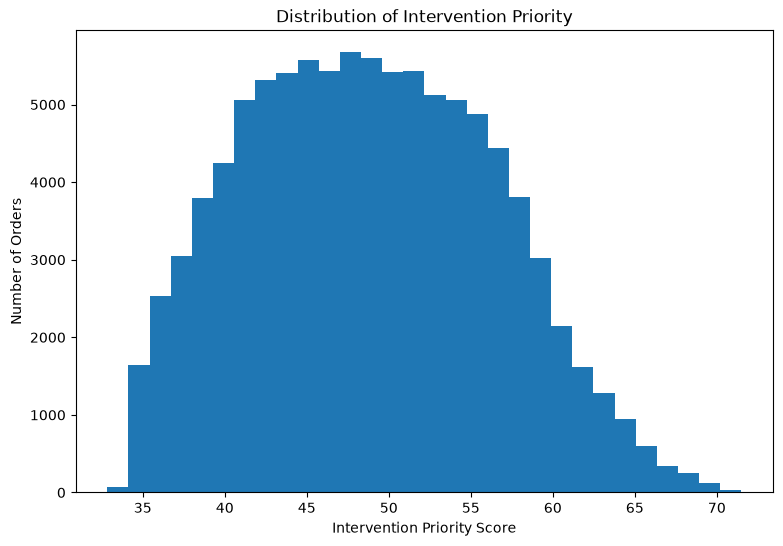

In [57]:
plt.figure(figsize=(9, 6))

plt.hist(
    df["priority_score"],
    bins=30
)

plt.xlabel("Intervention Priority Score")
plt.ylabel("Number of Orders")
plt.title("Distribution of Intervention Priority")

plt.show()

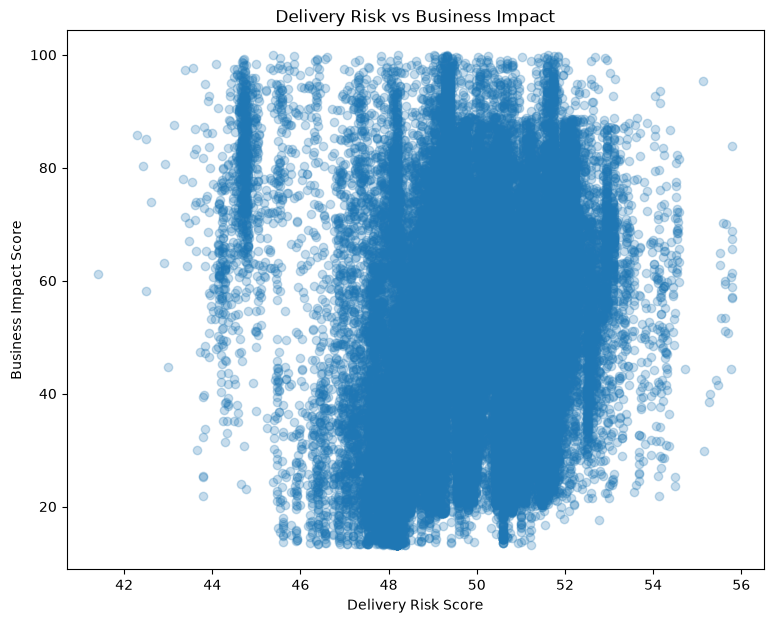

In [58]:
plt.figure(figsize=(9, 7))

plt.scatter(
    df["risk_score"],
    df["impact_score"],
    alpha=0.25
)

plt.xlabel("Delivery Risk Score")
plt.ylabel("Business Impact Score")
plt.title("Delivery Risk vs Business Impact")

plt.show()

In [59]:
intervention_output = df[
    [
        "order_id",
        "customer_state",
        "order_item_count",
        "product_count",
        "seller_count",
        "total_order_value",
        "freight_value",
        "late_probability",
        "risk_score",
        "risk_band",
        "impact_score",
        "priority_score",
        "intervention_tier",
        "recommended_action",
        "is_late"
    ]
].copy()

In [60]:
intervention_output.head()

,order_id,customer_state,order_item_count,product_count,seller_count,total_order_value,freight_value,late_probability,risk_score,risk_band,impact_score,priority_score,intervention_tier,recommended_action,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,1.0000,1.0000,1.0000,72.1900,13.2900,0.5071,50.7138,High,30.3250,42.5583,Standard Intervention,Monitor and review,0
1,00018f77f2f0320c557190d7a144bdd3,SP,1.0000,1.0000,1.0000,259.8300,19.9300,0.4970,49.6976,Medium,64.9136,55.7840,High Priority,Prioritize fulfillment monitoring,0
2,000229ec398224ef6ca0657da4fc703e,MG,1.0000,1.0000,1.0000,216.8700,17.8700,0.4968,49.6846,Medium,56.7322,52.5036,High Priority,Prioritize fulfillment monitoring,0
3,00024acbcdf0a6daa1e931b038114c75,SP,1.0000,1.0000,1.0000,25.7800,12.7900,0.4817,48.1683,Medium,21.6404,37.5571,Standard Intervention,Monitor and review,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,1.0000,1.0000,1.0000,218.0400,18.1400,0.4967,49.6670,Medium,57.1985,52.6796,High Priority,Prioritize fulfillment monitoring,0


In [61]:
import os

output_path = r"C:\Users\DELL\OneDrive\Desktop\supply-chain-operations-analytics\data\intervention_priority_output.csv"

# Automatically create the 'data' folder if it is missing
os.makedirs(os.path.dirname(output_path), exist_ok=True)

intervention_output.to_csv(
    output_path,
    index=False
)

print(f"Saved intervention dataset to: {output_path}")


Saved intervention dataset to: C:\Users\DELL\OneDrive\Desktop\supply-chain-operations-analytics\data\intervention_priority_output.csv


In [62]:
summary = {
    "total_orders": len(df),
    "late_orders": int(df["is_late"].sum()),
    "late_rate": df["is_late"].mean() * 100,
    "critical_orders": int(
        (df["intervention_tier"] == "Critical").sum()
    ),
    "high_priority_orders": int(
        (df["intervention_tier"] == "High Priority").sum()
    ),
    "avg_risk_score": df["risk_score"].mean(),
    "avg_priority_score": df["priority_score"].mean()
}

pd.DataFrame(
    [summary]
)

,total_orders,late_orders,late_rate,critical_orders,high_priority_orders,avg_risk_score,avg_priority_score
0,99441,7827,7.8710,0,42741,49.6525,48.8130


### Inspect the output we already created

In [63]:
# ============================================================
# OPTIMIZATION INPUT INSPECTION
# ============================================================

print("Rows:", len(intervention_output))
print("Columns:", len(intervention_output.columns))

print("\nColumns available:")
print(intervention_output.columns.tolist())

print("\nFirst 10 rows:")
display(intervention_output.head(10))

Rows: 99441
Columns: 15

Columns available:
['order_id', 'customer_state', 'order_item_count', 'product_count', 'seller_count', 'total_order_value', 'freight_value', 'late_probability', 'risk_score', 'risk_band', 'impact_score', 'priority_score', 'intervention_tier', 'recommended_action', 'is_late']

First 10 rows:


,order_id,customer_state,order_item_count,product_count,seller_count,total_order_value,freight_value,late_probability,risk_score,risk_band,impact_score,priority_score,intervention_tier,recommended_action,is_late
0,00010242fe8c5a6d1ba2dd792cb16214,RJ,1.0000,1.0000,1.0000,72.1900,13.2900,0.5071,50.7138,High,30.3250,42.5583,Standard Intervention,Monitor and review,0
1,00018f77f2f0320c557190d7a144bdd3,SP,1.0000,1.0000,1.0000,259.8300,19.9300,0.4970,49.6976,Medium,64.9136,55.7840,High Priority,Prioritize fulfillment monitoring,0
2,000229ec398224ef6ca0657da4fc703e,MG,1.0000,1.0000,1.0000,216.8700,17.8700,0.4968,49.6846,Medium,56.7322,52.5036,High Priority,Prioritize fulfillment monitoring,0
3,00024acbcdf0a6daa1e931b038114c75,SP,1.0000,1.0000,1.0000,25.7800,12.7900,0.4817,48.1683,Medium,21.6404,37.5571,Standard Intervention,Monitor and review,0
4,00042b26cf59d7ce69dfabb4e55b4fd9,SP,1.0000,1.0000,1.0000,218.0400,18.1400,0.4967,49.6670,Medium,57.1985,52.6796,High Priority,Prioritize fulfillment monitoring,0
5,00048cc3ae777c65dbb7d2a0634bc1ea,MG,1.0000,1.0000,1.0000,34.5900,12.6900,0.4826,48.2640,Medium,23.2692,38.2661,Standard Intervention,Monitor and review,0
6,00054e8431b9d7675808bcb819fb4a32,SP,1.0000,1.0000,1.0000,31.7500,11.8500,0.4817,48.1683,Medium,21.8018,37.6217,Standard Intervention,Monitor and review,0
7,000576fe39319847cbb9d288c5617fa6,SP,1.0000,1.0000,1.0000,880.7500,70.7500,0.4973,49.7265,Medium,71.8806,58.5882,High Priority,Prioritize fulfillment monitoring,0
8,0005a1a1728c9d785b8e2b08b904576c,SP,1.0000,1.0000,1.0000,157.6000,11.6500,0.4884,48.8398,Medium,59.5651,53.1299,High Priority,Prioritize fulfillment monitoring,1
9,0005f50442cb953dcd1d21e1fb923495,SP,1.0000,1.0000,1.0000,65.3900,11.4000,0.4825,48.2499,Medium,30.7360,41.2443,Standard Intervention,Monitor and review,0


In [64]:
# ============================================================
# INTERVENTION GRAIN CHECK
# ============================================================

print("Total rows:", len(intervention_output))

if "order_id" in intervention_output.columns:
    print(
        "Distinct orders:",
        intervention_output["order_id"].nunique()
    )

    print(
        "Duplicate order rows:",
        intervention_output["order_id"].duplicated().sum()
    )

Total rows: 99441
Distinct orders: 99441
Duplicate order rows: 0


In [65]:
# ============================================================
# INTERVENTION DISTRIBUTION
# ============================================================

print("\nIntervention Tier:")
print(
    intervention_output["intervention_tier"]
    .value_counts(dropna=False)
)

print("\nPriority Score:")
print(
    intervention_output["priority_score"].describe()
)

print("\nRisk Score:")
print(
    intervention_output["risk_score"].describe()
)


Intervention Tier:
intervention_tier
Standard Intervention    55176
High Priority            42741
NaN                       1524
Monitor                      0
Critical                     0
Name: count, dtype: int64

Priority Score:
count   97,917.0000
mean        48.8130
std          7.5260
min         32.8376
25%         42.8672
50%         48.5846
75%         54.4704
max         71.4965
Name: priority_score, dtype: float64

Risk Score:
count   99,441.0000
mean        49.6525
std          1.4780
min         41.4145
25%         48.4749
50%         49.4507
75%         50.7541
max         55.7989
Name: risk_score, dtype: float64


In [66]:
# ============================================================
# MISSING VALUES IN OPTIMIZATION INPUT
# ============================================================

intervention_output[
    ["risk_score", "priority_score", "intervention_tier"]
].isnull().sum()

risk_score              0
priority_score       1524
intervention_tier    1524
dtype: int64